In [1]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity

# ============================================================
# Single-site field operators from ladder operators
# ============================================================

def single_site_field_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Local Hilbert dimension
    # --------------------------------------------------------

    Nphi = 2**nq   # 64 for nq=6

    # --------------------------------------------------------
    # Ladder operator a
    # --------------------------------------------------------

    a = np.zeros((Nphi, Nphi), dtype=complex)

    for n in range(1, Nphi):

        a[n-1, n] = np.sqrt(n)

    # creation operator
    adag = a.conj().T

    # --------------------------------------------------------
    # Field operator
    #
    # Phi = (a + adag)/sqrt(2 mu)
    # --------------------------------------------------------

    Phi = (
        a + adag
    ) / np.sqrt(2 * mu)

    # --------------------------------------------------------
    # Conjugate momentum operator
    #
    # Pi = -i sqrt(mu/2) (a - adag)
    # --------------------------------------------------------

    Pi = (
        -1j
        * np.sqrt(mu / 2)
        * (a - adag)
    )

    # --------------------------------------------------------
    # Numerical Hermiticity cleanup
    # --------------------------------------------------------

    Phi = 0.5 * (Phi + Phi.conj().T)

    Pi = 0.5 * (Pi + Pi.conj().T)

    return csr_matrix(Phi), csr_matrix(Pi)


# ============================================================
# Two-site embedded operators
# ============================================================

def two_site_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(
        Nphi,
        format='csr',
        dtype=complex
    )

    # --------------------------------------------------------
    # Site 0 operators
    # --------------------------------------------------------

    Phi0 = kron(Phi, I, format='csr')
    Pi0  = kron(Pi,  I, format='csr')

    # --------------------------------------------------------
    # Site 1 operators
    # --------------------------------------------------------

    Phi1 = kron(I, Phi, format='csr')
    Pi1  = kron(I, Pi,  format='csr')

    return Phi0, Pi0, Phi1, Pi1


# ============================================================
# Example
# ============================================================

nq = 4
mu = 1.0

Phi0, Pi0, Phi1, Pi1 = two_site_operators(
    nq,
    mu
)

print("Hilbert dimension =", Phi0.shape[0])

print("Phi0 shape =", Phi0.shape)
print("Pi0 shape  =", Pi0.shape)

print("Phi1 shape =", Phi1.shape)
print("Pi1 shape  =", Pi1.shape)

Hilbert dimension = 256
Phi0 shape = (256, 256)
Pi0 shape  = (256, 256)
Phi1 shape = (256, 256)
Pi1 shape  = (256, 256)


In [2]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity
from scipy.sparse.linalg import eigsh

# ============================================================
# Local single-site Hamiltonian
# ============================================================

def single_site_hloc(Phi, Pi, mI2, lam, f):

    Phi2 = Phi @ Phi
    Phi4 = Phi2 @ Phi2
    Pi2  = Pi @ Pi

    hloc = (
        0.5 * Pi2
        + 0.5 * mI2 * Phi2
        + (lam / 24.0) * Phi4
        + f * Phi
    )

    return hloc




In [3]:
# ============================================================
# Two-site local Hamiltonian
# ============================================================

def two_site_hloc(nq, mu=1.0,
                  mI2=1.0,
                  lam=1.0,
                  f=-1e-3):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    # --------------------------------------------------------
    # Single-site local Hamiltonian
    # --------------------------------------------------------

    hloc = single_site_hloc(Phi, Pi, mI2, lam, f)

    # --------------------------------------------------------
    # Two-site Hamiltonian
    # H = h ⊗ I + I ⊗ h
    # --------------------------------------------------------

    Hloc = (
        kron(hloc, I, format='csr')
        +
        kron(I, hloc, format='csr')
    )

    return Hloc




In [4]:
# ============================================================
# Exact ground state
# ============================================================

def ground_state(H):

    # smallest algebraic eigenvalue
    evals, evecs = eigsh(H, k=1, which='SA')

    E0 = evals[0]
    psi0 = evecs[:, 0]

    # normalize explicitly
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0




In [5]:
# ============================================================
# Example
# ============================================================

nq   = 4
mu   = 1.0
mI2  = 1.0
lam  = 1.0
f    =- 0.5

Hloc = two_site_hloc(
    nq=nq,
    mu=mu,
    mI2=mI2,
    lam=lam,
    f=f
)

E0_loc, psi_loc = ground_state(Hloc)

print("Ground-state energy =", E0_loc)
print("State dimension     =", psi_loc.shape)
print("Norm                =", np.linalg.norm(psi_loc))

Ground-state energy = 0.8521615077493484
State dimension     = (256,)
Norm                = 1.0


In [6]:
# ============================================================
# Convert scalar-field Hamiltonian to Pauli form

# ============================================================

from qiskit.quantum_info import Operator, SparsePauliOp

# ============================================================
# Build two-site Hamiltonian
# ============================================================

Hloc = two_site_hloc(
    nq=4,
    mu=1.0,
    mI2=1.0,
    lam=1.0,
    f=-1e-5
)

# ============================================================
# Convert sparse matrix -> dense matrix
# ============================================================

H_dense = Hloc.toarray()

print("Dense Hamiltonian shape =", H_dense.shape)

# ============================================================
# Convert to Qiskit Operator
# ============================================================

H_op = Operator(H_dense)

# ============================================================
# Convert to SparsePauliOp
# ============================================================

print("\nConverting to Pauli representation...\n")

H_pauli = SparsePauliOp.from_operator(H_op)

# ============================================================
# Remove tiny coefficients
# ============================================================

H_pauli = H_pauli.simplify(atol=1e-10)

print("Done.")

# ============================================================
# Number of Pauli terms
# ============================================================

print("\nNumber of Pauli terms =", len(H_pauli))

# ============================================================
# Show first few Pauli terms
# ============================================================

print("\nFirst few Pauli terms:\n")

for pauli, coeff in zip(
    H_pauli.paulis[:10],
    H_pauli.coeffs[:10]
):

    print(f"{coeff:.6f} * {pauli}")

Dense Hamiltonian shape = (256, 256)

Converting to Pauli representation...

Done.

Number of Pauli terms = 111

First few Pauli terms:

24.062500+0.000000j * IIIIIIII
-0.000019+0.000000j * IIIIIIIX
3.203275+0.000000j * IIIIIIXI
-0.031443+0.000000j * IIIIIIXZ
-0.687500+0.000000j * IIIIIIZI
-0.937500+0.000000j * IIIIIIZZ
0.833067+0.000000j * IIIIIXII
-0.083419+0.000000j * IIIIIXIZ
1.669265+0.000000j * IIIIIXXI
-0.166668+0.000000j * IIIIIXXZ


In [7]:
# ============================================================
# Remove identity offset
# ============================================================

coeffs = H_pauli.coeffs
paulis = H_pauli.paulis

new_coeffs = []
new_paulis = []

identity_shift = 0.0

for p, c in zip(paulis, coeffs):

    if str(p) == 'I' * nq:

        identity_shift += np.real(c)

    else:

        new_paulis.append(p)
        new_coeffs.append(c)

H_pauli_shifted = SparsePauliOp(
    new_paulis,
    coeffs=new_coeffs
)

print("Removed identity shift =", identity_shift)

print("Remaining Pauli terms =",
      len(H_pauli_shifted))

Removed identity shift = 0.0
Remaining Pauli terms = 111


In [8]:
# ============================================================
# Hamiltonian Variational Ansatz (HVA) VQE
# ============================================================

import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import L_BFGS_B

# ============================================================
# Physics-Inspired HVA for Scalar Field Hamiltonian
# ============================================================

def grouped_hva_asymm(nq, layers):

    qc = QuantumCircuit(nq)

    # --------------------------------------------------------
    # Tiny symmetry-breaking seed
    # --------------------------------------------------------
    for q in range(nq):
        qc.ry(0.01, q)

    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------

    nparams_per_layer = 2 * nq + 1

    params = ParameterVector(
    "θ",
    nparams_per_layer * layers
    )

    p = 0

    for l in range(layers):
        offset = l * nparams_per_layer
        θx = params[offset : offset + nq]
        

        θz = params[offset + nq : offset + 2 * nq]

        

        θzz = params[offset + 2 * nq]
        

        # ----------------------------------------------------
        # X sector
        # exp(-i θ Σ X)
        # ----------------------------------------------------

        for q in range(nq):
            qc.rx(2 * θx[q], q)

        # ----------------------------------------------------
        # Z sector
        # exp(-i θ Σ Z)
        # ----------------------------------------------------

        for q in range(nq):
            qc.rz(2 * θz[q], q)

        # ----------------------------------------------------
        # ZZ sector
        # exp(-i θ Σ ZZ)
        # ----------------------------------------------------

        # Even bonds
        for q in range(0, nq - 1, 2):

            qc.cx(q, q + 1)
            qc.rz(2 * θzz, q + 1)
            qc.cx(q, q + 1)

        # Odd bonds
        for q in range(1, nq - 1, 2):
            qc.cx(q, q + 1)
            qc.rz(2 * θzz, q + 1)
            qc.cx(q, q + 1)

        p += 3

    return qc




In [9]:
# ============================================================
# Hamiltonian Variational Ansatz (HVA) VQE
# ============================================================

import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import L_BFGS_B

# ============================================================
# Physics-Inspired HVA for Scalar Field Hamiltonian
# ============================================================

def grouped_hva_symm(nq, layers):

    qc = QuantumCircuit(nq)

    # --------------------------------------------------------
    # Tiny symmetry-breaking seed
    # --------------------------------------------------------

    for q in range(nq):
        qc.ry(0.01, q)

    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------

    nparams_per_layer = 2 * nq + 1

    params = ParameterVector(
    "θ",
    nparams_per_layer * layers
    )

    p = 0

    for l in range(layers):
        offset = l * nparams_per_layer
        θx = params[offset : offset + nq]
        

        θz = params[offset + nq : offset + 2 * nq]

        

        θzz = params[offset + 2 * nq]
        

        # ----------------------------------------------------
        # X sector
        # exp(-i θ Σ X)
        # ----------------------------------------------------

        for q in range(nq):
            qc.rx(2 * θx[q], q)

        # ----------------------------------------------------
        # Z sector
        # exp(-i θ Σ Z)
        # ----------------------------------------------------

        for q in range(nq):
            qc.rz(2 * θz[q], q)

        # ----------------------------------------------------
        # ZZ sector
        # exp(-i θ Σ ZZ)
        # ----------------------------------------------------

        # Even bonds
        for q in range(0, nq - 1, 2):

            qc.cx(q, q + 1)
            qc.rz(2 * θzz, q + 1)
            qc.cx(q, q + 1)

        # Odd bonds
        for q in range(1, nq - 1, 2):

            qc.cx(q, q + 1)
            qc.rz(2 * θzz, q + 1)
            qc.cx(q, q + 1)

        p += 3

    return qc




In [10]:
###### Exact Ground State Utility

# ============================================================
# Exact ground state from sparse Hamiltonian
# ============================================================

from scipy.sparse.linalg import eigsh


def exact_ground_state(H_sparse):

    evals, evecs = eigsh(H_sparse, k=1, which='SA')

    E0 = np.real(evals[0])

    psi0 = evecs[:, 0]
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0


In [11]:
##### Fidelity Function

def fidelity(psi_exact, psi_vqe):

    return np.abs(np.vdot(psi_exact, psi_vqe))**2

In [12]:
# ============================================================
# Multi-parameter scan
# HVA + warm-start continuation + overlap tracking
# ============================================================

from qiskit.quantum_info import Statevector
from qiskit_algorithms.optimizers import L_BFGS_B

# ------------------------------------------------------------
# Fixed parameters
# ------------------------------------------------------------

nq_site = 4
nqubits = 2 * nq_site

mu = 1.0

# Default depth
layers = 4

# ------------------------------------------------------------
# Number of VQE restarts
# ------------------------------------------------------------

n_restarts = 5

# ------------------------------------------------------------
# Energy tolerance
# ------------------------------------------------------------

energy_tol = 1e-3

# ------------------------------------------------------------
# Parameter sets
# ------------------------------------------------------------

parameter_sets = [

    {
        "label": "Symmetric",
        "mI2": 1.0,
        "f": 0.0
    },

    {
        "label": "Weak SSB",
        "mI2": -1.0,
        "f": -1e-5
    },
    
    {
        "label": "Weak SSB optimised",
        "mI2": -1.0,
        "f": -5*1e-2
    },
   {
        "label": "Strong SSB",
        "mI2": -1.0,
        "f": -0.5
    }
]

# ------------------------------------------------------------
# Lambda values
# ------------------------------------------------------------

lambda_list = np.linspace(0.1, 2.0, 10)

# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

all_results = []

# ============================================================
# Main loop
# ============================================================

for params in parameter_sets:

    label = params["label"]
    mI2 = params["mI2"]
    f = params["f"]

    print("\n")
    print("#" * 80)
    print(f"CASE: {label}")
    print(f"mI² = {mI2},  f = {f}")
    print("#" * 80)

    case_results = []

    # --------------------------------------------------------
    # Tracking variables
    # --------------------------------------------------------

    previous_state = None
    previous_optimal_point = None

    # ========================================================
    # Lambda loop
    # ========================================================

    for lam in lambda_list:

        print("\n" + "=" * 60)
        print(f"Running λ = {lam:.3f}")
        print("=" * 60)

        # ----------------------------------------------------
        # Build H_loc
        # ----------------------------------------------------

        Hloc_sparse = two_site_hloc(
            nq=nq_site,
            mu=mu,
            mI2=mI2,
            lam=lam,
            f=f
        )

        # ----------------------------------------------------
        # Exact ground state
        # ----------------------------------------------------

        E_exact, psi_exact = exact_ground_state(
            Hloc_sparse
        )

        # ----------------------------------------------------
        # Dense Hamiltonian
        # ----------------------------------------------------

        H_dense = Hloc_sparse.toarray()

        # ----------------------------------------------------
        # Convert to Pauli form
        # ----------------------------------------------------

        H_op = Operator(H_dense)

        H_pauli = SparsePauliOp.from_operator(
            H_op
        )

        # ----------------------------------------------------
        # Remove identity shift
        # ----------------------------------------------------

        coeffs = H_pauli.coeffs
        paulis = H_pauli.paulis

        new_coeffs = []
        new_paulis = []

        identity_shift = 0.0

        for p, c in zip(paulis, coeffs):

            if str(p) == 'I' * nqubits:

                identity_shift += np.real(c)

            else:

                new_paulis.append(p)
                new_coeffs.append(c)

        H_pauli_shifted = SparsePauliOp(
            new_paulis,
            coeffs=new_coeffs
        )

        # ====================================================
        # Adaptive depth near critical region
        # ====================================================

        

        # ====================================================
        # Ansatz
        # ====================================================

        if mI2 < 0:

            ansatz = grouped_hva_asymm(
                nq=nqubits,
                layers=layers
            )

        else:

            ansatz = grouped_hva_symm(
                nq=nqubits,
                layers=layers
            )

        # ----------------------------------------------------
        # Estimator
        # ----------------------------------------------------

        estimator = StatevectorEstimator()

        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer = L_BFGS_B(maxiter=1000)



        
        # ====================================================
        # Weak SSB:
        # warm-start + overlap tracking
        # ====================================================

        if mI2 < 0 :

            print(
                "\nRunning HVA-VQE "
                "with warm-start tracking...\n"
            )

            candidate_states = []

            # ------------------------------------------------
            # Multiple restarts
            # ------------------------------------------------

            for trial in range(n_restarts):

                print(f"\nRestart {trial}")

                # --------------------------------------------
                # Initial point
                # --------------------------------------------

                if (
                    trial == 0
                    and previous_optimal_point is not None
                ):

                    initial_point = (
                        previous_optimal_point
                    )

                else:

                    initial_point = (
                        0.01 * np.random.randn(
                            ansatz.num_parameters
                        )
                    )

                # --------------------------------------------
                # VQE
                # --------------------------------------------

                vqe = VQE(
                    estimator=estimator,
                    ansatz=ansatz,
                    optimizer=optimizer,
                    initial_point=initial_point
                )

                result = (
                    vqe.compute_minimum_eigenvalue(
                        H_pauli_shifted
                    )
                )

                # --------------------------------------------
                # Physical energy
                # --------------------------------------------

                E_trial = (
                    result.eigenvalue.real
                    + identity_shift
                )

                # --------------------------------------------
                # Trial circuit
                # --------------------------------------------

                qc_trial = (
                    ansatz.assign_parameters(
                        result.optimal_parameters
                    )
                )

                # --------------------------------------------
                # Trial state
                # --------------------------------------------

                psi_trial = (
                    Statevector.from_instruction(
                        qc_trial
                    ).data
                )

                # --------------------------------------------
                # Fidelity
                # --------------------------------------------

                fidelity_trial = np.abs(
                    np.vdot(
                        psi_exact,
                        psi_trial
                    )
                )**2

                # --------------------------------------------
                # Overlap tracking
                # --------------------------------------------

                if previous_state is None:

                    overlap = 1.0

                else:

                    overlap = np.abs(
                        np.vdot(
                            previous_state,
                            psi_trial
                        )
                    )**2

                print(
                    f"Energy   = {E_trial:.12f}"
                )

                print(
                    f"Fidelity = {fidelity_trial:.12f}"
                )

                print(
                    f"Overlap  = {overlap:.12f}"
                )

                # --------------------------------------------
                # Store candidate
                # --------------------------------------------

                candidate_states.append({

                    "energy": E_trial,
                    "state": psi_trial,
                    "result": result,
                    "fidelity": fidelity_trial,
                    "overlap": overlap

                })

            # ------------------------------------------------
            # Minimum energy
            # ------------------------------------------------

            min_energy = min(
                c["energy"]
                for c in candidate_states
            )

            # ------------------------------------------------
            # Low-energy manifold
            # ------------------------------------------------

            filtered_candidates = [

                c for c in candidate_states

                if (
                    c["energy"] - min_energy
                ) < energy_tol
            ]

            # ------------------------------------------------
            # Select maximum overlap
            # ------------------------------------------------

            best_candidate = max(

                filtered_candidates,

                key=lambda x: x["overlap"]

            )

            # ------------------------------------------------
            # Final selected state
            # ------------------------------------------------

            best_energy = (
                best_candidate["energy"]
            )

            best_state = (
                best_candidate["state"]
            )

            best_result = (
                best_candidate["result"]
            )

            best_fidelity = (
                best_candidate["fidelity"]
            )

            best_overlap = (
                best_candidate["overlap"]
            )

            # ------------------------------------------------
            # Update tracking variables
            # ------------------------------------------------

            previous_state = best_state.copy()

            previous_optimal_point = (
                best_result.optimal_point
            )
     
        # ====================================================
        # Symmetric + Strong SSB
        # ====================================================

        else:

            print(
                "\nRunning ordinary HVA-VQE...\n"
            )

            initial_point = (
                0.01 * np.random.randn(
                    ansatz.num_parameters
                )
            )

            vqe = VQE(
                estimator=estimator,
                ansatz=ansatz,
                optimizer=optimizer,
                initial_point=initial_point
            )

            result = (
                vqe.compute_minimum_eigenvalue(
                    H_pauli_shifted
                )
            )

            best_energy = (
                result.eigenvalue.real
                + identity_shift
            )

            optimal_circuit = (
                ansatz.assign_parameters(
                    result.optimal_parameters
                )
            )

            best_state = (
                Statevector.from_instruction(
                    optimal_circuit
                ).data
            )

            best_fidelity = np.abs(
                np.vdot(
                    psi_exact,
                    best_state
                )
            )**2

            best_overlap = 1.0

        # ====================================================
        # Final VQE data
        # ====================================================

        E_vqe = best_energy
        F = best_fidelity

        # ====================================================
        # Store results
        # ====================================================

        data = {

            "case": label,

            "lambda": lam,

            "mI2": mI2,

            "f": f,
            'psi_vqe': best_state,

            "E_exact": E_exact,

            "E_vqe": E_vqe,

            "error": abs(
                E_exact - E_vqe
            ),

            "fidelity": F,

            "tracking_overlap": best_overlap,

            "layers": layers
        }

        case_results.append(data)
        all_results.append(data)

        # ====================================================
        # Print
        # ====================================================

        print("\nFINAL SELECTED STATE")

        print(
            f"Exact energy     : "
            f"{E_exact:.12f}"
        )

        print(
            f"VQE energy       : "
            f"{E_vqe:.12f}"
        )

        print(
            f"Energy error     : "
            f"{abs(E_exact - E_vqe):.6e}"
        )

        print(
            f"Fidelity         : "
            f"{F:.12f}"
        )

        print(
            f"Tracking overlap : "
            f"{best_overlap:.12f}"
        )

        print(
            f"Layers            : "
            f"{layers}"
        )

        print(
            f"Pauli terms       : "
            f"{len(H_pauli_shifted.paulis)}"
        )

    # ========================================================
    # Summary
    # ========================================================

    print("\n")
    print("=" * 140)
    print(f"SUMMARY : {label}")
    print("=" * 140)

    print(
        f"{'lambda':<12}"
        f"{'Exact E':<20}"
        f"{'VQE E':<20}"
        f"{'Error':<18}"
        f"{'Fidelity':<18}"
        f"{'TrackOverlap':<18}"
        f"{'Layers':<10}"
    )

    print("=" * 140)

    for r in case_results:

        print(
            f"{r['lambda']:<12.4f}"
            f"{r['E_exact']:<20.10f}"
            f"{r['E_vqe']:<20.10f}"
            f"{r['error']:<18.4e}"
            f"{r['fidelity']:<18.10f}"
            f"{r['tracking_overlap']:<18.10f}"
            f"{r['layers']:<10}"
        )



################################################################################
CASE: Symmetric
mI² = 1.0,  f = 0.0
################################################################################

Running λ = 0.100

Running ordinary HVA-VQE...


FINAL SELECTED STATE
Exact energy     : 1.006161728159
VQE energy       : 1.006162024540
Energy error     : 2.963814e-07
Fidelity         : 0.999999939049
Tracking overlap : 1.000000000000
Layers            : 4
Pauli terms       : 106

Running λ = 0.311

Running ordinary HVA-VQE...


FINAL SELECTED STATE
Exact energy     : 1.018641427347
VQE energy       : 1.018642416536
Energy error     : 9.891888e-07
Fidelity         : 0.999999845780
Tracking overlap : 1.000000000000
Layers            : 4
Pauli terms       : 108

Running λ = 0.522

Running ordinary HVA-VQE...


FINAL SELECTED STATE
Exact energy     : 1.030499309794
VQE energy       : 1.030504369440
Energy error     : 5.059646e-06
Fidelity         : 0.999999263462
Tracking overlap : 1.0000

In [13]:
print(sorted(set(x['case'] for x in all_results)))

['Strong SSB', 'Symmetric', 'Weak SSB', 'Weak SSB optimised']


In [14]:
print(all_results[0])

{'case': 'Symmetric', 'lambda': np.float64(0.1), 'mI2': 1.0, 'f': 0.0, 'psi_vqe': array([ 4.80359764e-01+8.77048785e-01j,  7.93302035e-06+1.95866914e-05j,
       -2.06790563e-03-3.77472316e-03j,  1.57153787e-04-7.84422905e-05j,
       -5.68475598e-04-1.03534503e-03j, -6.42683741e-09-1.02937815e-08j,
        6.98766102e-05-3.28046207e-05j,  4.64599296e-07-5.99799386e-08j,
        1.64005529e-07+7.29079131e-06j, -1.54386140e-11+1.53489321e-10j,
        1.28161543e-09-2.57417728e-08j,  1.28512499e-09+7.16770449e-11j,
        7.35153631e-05-2.52970574e-05j,  1.59428454e-09-2.87388299e-10j,
        5.97025304e-08+6.46571673e-08j, -5.63095222e-10-1.24479953e-08j,
        1.24216269e-06+4.95383982e-06j,  1.39306418e-11+1.07025872e-10j,
       -5.34876863e-09-2.13215015e-08j,  8.77805458e-10-1.84868920e-10j,
       -1.64629254e-09-2.73024379e-09j, -3.19722609e-14+4.55880324e-15j,
        3.84514520e-10-7.06347978e-11j,  2.84683639e-12+4.72116470e-13j,
        3.96376593e-05-4.61726340e-06j,  8

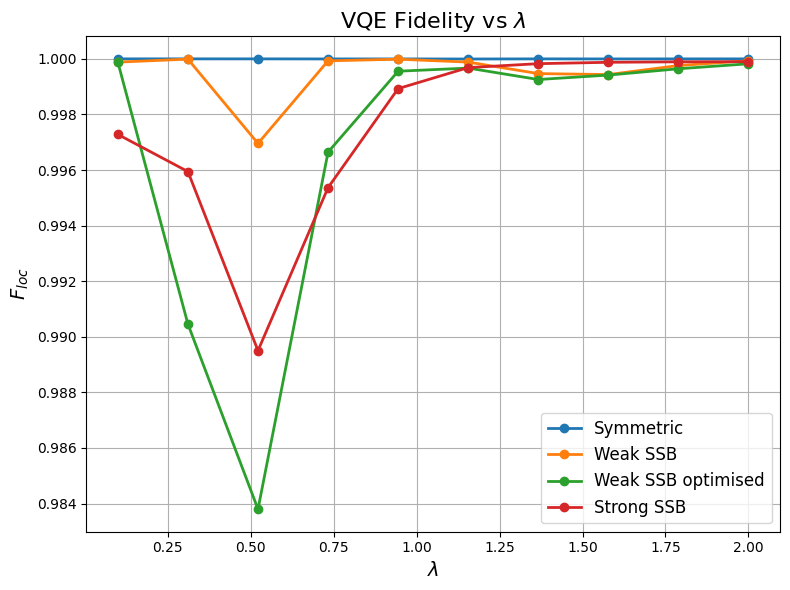

In [15]:
# ============================================================
# Plot : Fidelity vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------

cases = {}

for r in all_results:

    label = r['case']

    if label not in cases:

        cases[label] = {
            'lambda': [],
            'fidelity': []
        }

    cases[label]['lambda'].append(r['lambda'])
    cases[label]['fidelity'].append(r['fidelity'])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

for label, data in cases.items():

    plt.plot(
        data['lambda'],
        data['fidelity'],
        marker='o',
        linewidth=2,
        label=label
    )

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$F_{loc}$', fontsize=14)

plt.title(
    r'VQE Fidelity vs $\lambda$',
    fontsize=16
)

plt.grid(True)

plt.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "HVA_Floc vs lambda different f.pdf",
    bbox_inches='tight'
)

plt.show()

In [16]:
# ============================================================
# H_c
# ============================================================

def two_site_hc(

    nq,

    mu=1.0,

    m0_sq=1.0,

    mI2=1.0
):

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    Phi0 = kron(Phi, I, format='csr')

    Phi1 = kron(I, Phi, format='csr')

    Hc = (

        0.5 * (
            (Phi1 - Phi0) @ (Phi1 - Phi0)
        )

        +

        0.5 * (m0_sq - mI2) * (

            (Phi0 @ Phi0)

            +

            (Phi1 @ Phi1)
        )
    )

    return Hc

In [17]:
# ============================================================
# H_s
# ============================================================

def two_site_hs(

    nq,

    mu=1.0,

    mI2=1.0,

    m0_sq=1.0,

    lam=1.0,

    f=0.0,

    s=1.0
):

    Hloc = two_site_hloc(

        nq=nq,

        mu=mu,

        mI2=mI2,

        lam=lam,

        f=f
    )

    Hc = two_site_hc(

        nq=nq,

        mu=mu,

        m0_sq=m0_sq,

        mI2=mI2
    )

    return Hloc + s * Hc


In [18]:
# ============================================================
# Exact ground state
# ============================================================

def exact_ground_state(H):

    H_dense = H.toarray()

    eigvals, eigvecs = np.linalg.eigh(H_dense)

    return eigvals[0], eigvecs[:, 0]

In [19]:
# ============================================================
# Minimum instantaneous gap along adiabatic path
# ============================================================

def minimum_gap_along_path(

    nq,

    mu,

    mI2,

    m0_sq,

    lam,

    f,

    nsteps=100
):

    gap_min = 1e100

    for step in range(nsteps):

        s = step / nsteps

        Hs = two_site_hs(

            nq=nq,

            mu=mu,

            mI2=mI2,

            m0_sq=m0_sq,

            lam=lam,

            f=f,

            s=s
        )

        evals, _ = eigsh(

            Hs,

            k=2,

            which='SA'
        )

        evals = np.sort(np.real(evals))

        gap = evals[1] - evals[0]

        gap_min = min(gap_min, gap)

    return gap_min

In [20]:
# ============================================================
# One Trotter step
# ============================================================
from scipy.linalg import expm
def trotter_step_unitary(

    nq,

    dt,

    mu,

    mI2,

    m0_sq,

    lam,

    f,

    s
):

    Hs = two_site_hs(

        nq=nq,

        mu=mu,

        mI2=mI2,

        m0_sq=m0_sq,

        lam=lam,

        f=f,

        s=s
    )

    U = expm(

        -1j * Hs.toarray() * dt

    )

    return U

In [21]:
# ============================================================
# Adiabatic circuit evolution
# ============================================================

def adiabatic_circuit_evolution(

    initial_state,

    nq,

    T,

    mu,

    mI2,

    m0_sq,

    lam,

    f,

    nsteps=100
):

    nqubits = 2 * nq

    dt = T / nsteps

    psi = Statevector(initial_state)

    # --------------------------------------------------------
    # Time evolution
    # --------------------------------------------------------

    for step in range(nsteps):

        t = step * dt

        s = t / T

        # ----------------------------------------------------
        # Instantaneous unitary
        # ----------------------------------------------------

        U = trotter_step_unitary(

            nq=nq,

            dt=dt,

            mu=mu,

            mI2=mI2,

            m0_sq=m0_sq,

            lam=lam,

            f=f,

            s=s
        )

        # ----------------------------------------------------
        # Quantum circuit
        # ----------------------------------------------------

        qc = QuantumCircuit(nqubits)

        qc.unitary(U, range(nqubits))

        # ----------------------------------------------------
        # Evolve state
        # ----------------------------------------------------

        psi = psi.evolve(qc)

    return psi.data

In [72]:
def find_lambda_c(lams, d2M, d3M, dM):

    best_lambda = np.nan
    best_response = -np.inf

    for i in range(len(lams)-1):

        if d2M[i] * d2M[i+1] <= 0:

            # linear interpolation for d2M = 0
            x1, x2 = lams[i], lams[i+1]
            y1, y2 = d2M[i], d2M[i+1]

            lam = x1 - y1*(x2-x1)/(y2-y1)

            # interpolate dM at the same point
            dm = dM[i] + (dM[i+1]-dM[i])*(lam-x1)/(x2-x1)

            if abs(dm) > best_response:
                best_response = abs(dm)
                best_lambda = lam

    return best_lambda

In [73]:
# ============================================================
# T scan values
# ============================================================

T_values = [

    1,2,5,10,20,30,40,50,75,100,
    125,150,175,200,225,250,275,300,
    400,500,600,700,800,900,
    1000,1010,1020,1030,1040,1050,
    1060,1070,1080,1090,1100,
    1200,1300,1400,1500,
    2000,
    2100,2110,2120,2130,2140,
    2150,2160,2170,2180,2190,
    2200,2300,2400,2500,
    2600,2700,2800,2900,3000
]

target_fidelity = 0.97

# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================

for data in all_results:

    label   = data['case']
    lam     = data['lambda']
    mI2     = data['mI2']
    f       = data['f']
    psi_vqe = data['psi_vqe']

    
    print("\n")
    print("="*80)
    print(f"CASE   : {label}")
    print(f"lambda : {lam:.3f}")
    print("="*80)

    # ========================================================
    # Final Hamiltonian
    # ========================================================

    Hs_final = two_site_hs(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=1.0,

        lam=lam,

        f=f,

        s=1.0
    )

    E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
    )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

    delta_min = minimum_gap_along_path(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=1.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    print(f"Minimum path gap = {delta_min:.8e}")

    # ========================================================
    # Scan T
    # ========================================================

    Tmin_found = None
    best_fidelity = 0.0

    for T in T_values:

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=T,

            mu=mu,

            mI2=mI2,

            m0_sq=1.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        F = fidelity(
            psi_T,
            psi_exact_final
        )

        best_fidelity = max(
            best_fidelity,
            F
        )

        print(
            f"T = {T:<5} "
            f"Fidelity = {F:.8f}"
        )

        if F >= target_fidelity:

            Tmin_found = T
            break

    # ========================================================
    # Diagnostics
    # ========================================================

    P0 = None
    P1 = None
    P01 = None
    final_gap = None

    if Tmin_found is None:

        print("\nFAILED POINT DIAGNOSTICS")

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=3000,

            mu=mu,

            mI2=mI2,

            m0_sq=1.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        evals, evecs = eigsh(

            Hs_final,

            k=3,

            which='SA'
        )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

        P0 = np.abs(np.vdot(psi0, psi_T))**2
        P1 = np.abs(np.vdot(psi1, psi_T))**2
        P01 = P0 + P1

        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
        print(f"P0     = {P0:.8f}")
        print(f"P1     = {P1:.8f}")
        print(f"P0+P1  = {P01:.8f}")

    # ========================================================
    # Store
    # ========================================================

    adiabatic_results.append({

        'case': label,
        'lambda': lam,
        'mI2': mI2,
        'f': f,
        'psi_vqe': psi_vqe,
        'Tmin': Tmin_found,

        'best_fidelity': best_fidelity,

        'delta_min': delta_min,

        'P0': P0,
        'P1': P1,
        'P01': P01,

        'final_gap': final_gap
    })

    print(
        f"\nMinimum T for Fidelity >= 0.97 : "
        f"{Tmin_found}"
    )

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    f"{'T_min':<10}"
    f"{'Best Fidelity':<18}"
    f"{'Delta_min':<18}"
    f"{'P0':<12}"
    f"{'P1':<12}"
    f"{'P0+P1':<12}"
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        f"{str(r['Tmin']):<10}"
        f"{r['best_fidelity']:<18.10f}"
        f"{r['delta_min']:<18.8e}"
        f"{str(None if r['P0'] is None else round(r['P0'],6)):<12}"
        f"{str(None if r['P1'] is None else round(r['P1'],6)):<12}"
        f"{str(None if r['P01'] is None else round(r['P01'],6)):<12}"
    )



CASE   : Symmetric
lambda : 0.100
Minimum path gap = 1.00972087e+00
T = 1     Fidelity = 0.98119711

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 0.311
Minimum path gap = 1.02934439e+00
T = 1     Fidelity = 0.98267824

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 0.522
Minimum path gap = 1.04790824e+00
T = 1     Fidelity = 0.98394678

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 0.733
Minimum path gap = 1.06556366e+00
T = 1     Fidelity = 0.98503194

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 0.944
Minimum path gap = 1.08242773e+00
T = 1     Fidelity = 0.98598970

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 1.156
Minimum path gap = 1.09859358e+00
T = 1     Fidelity = 0.98685027

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 1.367
Minimum path gap = 1.11413694e+00
T = 1     Fidelity = 0.98761479

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 1.57

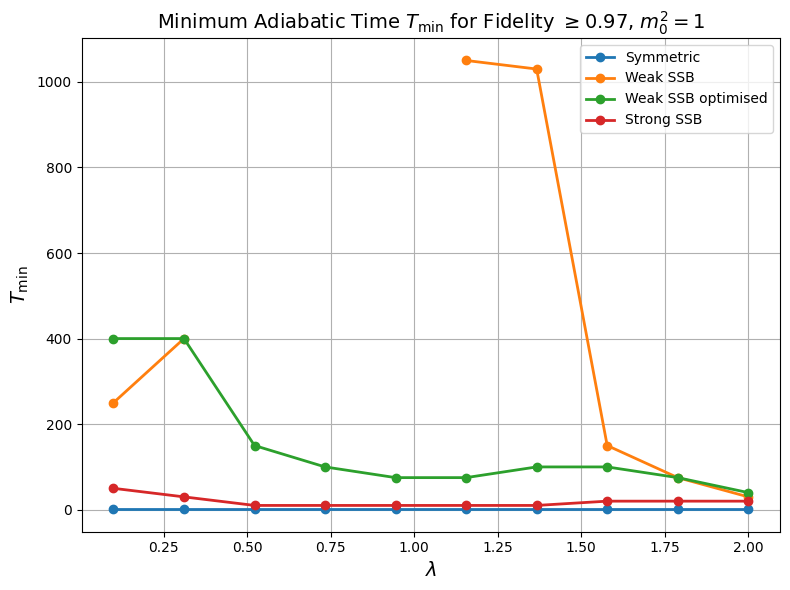

In [74]:
# ============================================================
# Plot T_min vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# Separate data by case
# ============================================================

case_data = {}

for r in adiabatic_results:

    case = r['case']

    if case not in case_data:

        case_data[case] = {

            'lambda': [],

            'Tmin': []
        }

    case_data[case]['lambda'].append(

        r['lambda']
    )

    case_data[case]['Tmin'].append(

        r['Tmin']
    )

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,6))

for case, d in case_data.items():

    plt.plot(

        d['lambda'],

        d['Tmin'],

        marker='o',

        linewidth=2,

        label=case
    )

# ============================================================
# Labels
# ============================================================

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$T_{\min}$', fontsize=14)

plt.title(

    r'Minimum Adiabatic Time $T_{\min}$ '
    r'for Fidelity $\geq 0.97$, $m_{0}^{2}=1$',

    fontsize=14
)

plt.grid(True)

plt.legend()

plt.tight_layout()
plt.savefig(
    "HEA_adiabatic time vs lambda.pdf",
    bbox_inches='tight'
)
plt.show()

In [75]:
# ============================================================
# GAP ANALYSIS
# ============================================================

from scipy.sparse.linalg import eigsh

gap_sym = []
gap_weak_opt = []
gap_strong = []

# ------------------------------------------------------------
# Symmetric
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=1.0,
        m0_sq=1.0,
        lam=lam,
        f=0.0,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_sym.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Weak SSB optimized
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=1.0,
        lam=lam,
        f=5*1e-2,          # optimized value
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_weak_opt.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Strong SSB
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=1.0,
        lam=lam,
        f=0.5,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_strong.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Critical λ
# ------------------------------------------------------------

lamc_sym = lambda_list[np.argmin(gap_sym)]
lamc_weak = lambda_list[np.argmin(gap_weak_opt)]
lamc_strong = lambda_list[np.argmin(gap_strong)]

print("\nGap minimum estimator")
print("----------------------")
print(f"Symmetric       λc = {lamc_sym:.4f}")
print(f"Weak SSB opt    λc = {lamc_weak:.4f}")
print(f"Strong SSB      λc = {lamc_strong:.4f}")


Gap minimum estimator
----------------------
Symmetric       λc = 0.1000
Weak SSB opt    λc = 0.1000
Strong SSB      λc = 0.1000


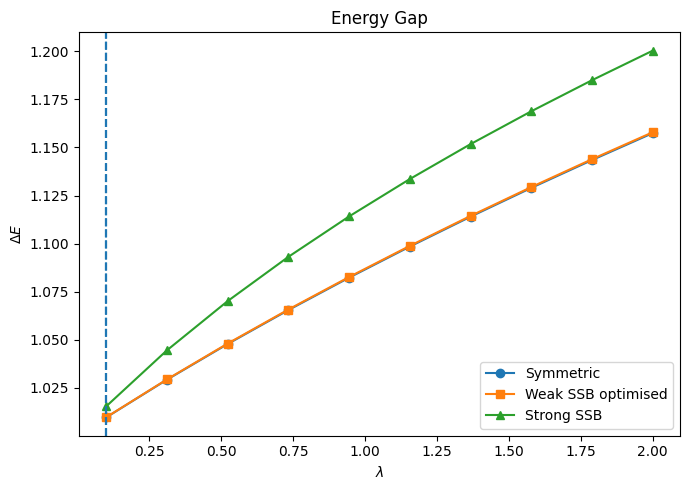

In [76]:
# ============================================================
# Plot : Gap vs lambda
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(lambda_list, gap_sym,
         'o-', label='Symmetric')

plt.plot(lambda_list, gap_weak_opt,
         's-', label='Weak SSB optimised')

plt.plot(lambda_list, gap_strong,
         '^-', label='Strong SSB')

plt.axvline(lamc_sym,
            ls='--')

plt.axvline(lamc_weak,
            ls='--')

plt.axvline(lamc_strong,
            ls='--')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Delta E$')
plt.title('Energy Gap')
plt.legend()

plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# Order parameter operator
# ============================================================

Phi0, Pi0, Phi1, Pi1 = two_site_operators(

    nq_site,

    mu
)

Phi_avg = 0.5 * (Phi0 + Phi1)

In [78]:
print(adiabatic_results[0].keys())

dict_keys(['case', 'lambda', 'mI2', 'f', 'psi_vqe', 'Tmin', 'best_fidelity', 'delta_min', 'P0', 'P1', 'P01', 'final_gap'])


In [79]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []

for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    Tmin = r['Tmin']

    mI2 = r['mI2']

    f = r['f']

    match = next(
        x for x in all_results
        if (
            x['case'] == case
            and np.isclose(x['lambda'], lam)
        )
    )

    psi_vqe = match['psi_vqe']

    psi_final = adiabatic_circuit_evolution(

        initial_state=psi_vqe,

        nq=nq_site,

        T=Tmin,

        mu=mu,

        mI2=mI2,

        m0_sq=1.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    M = np.real(

        np.vdot(

            psi_final,

            Phi_avg @ psi_final
        )
    )

    if case == "Symmetric":
    
        M_sym.append(M)

    elif case == "Weak SSB optimised":
        #print(psi_final)
        #print(Phi_avg)

        M_weak_opt.append(M)

    elif case == "Strong SSB":

        M_strong.append(M)

dict_keys(['case', 'lambda', 'mI2', 'f', 'psi_vqe', 'Tmin', 'best_fidelity', 'delta_min', 'P0', 'P1', 'P01', 'final_gap'])


In [80]:
print(M_weak_opt)

[np.float64(-0.04140902430626048), np.float64(0.11374196678319333), np.float64(0.023384821268767182), np.float64(-0.07490307880145866), np.float64(0.19301121407624305), np.float64(-0.0866168641512424), np.float64(0.001162622860203806), np.float64(0.04853000624566695), np.float64(-0.03885554511630915), np.float64(0.1066495972983043)]


In [81]:
#============================================================
# λc from inflection point
# ============================================================

# First derivatives

dM_sym = np.gradient(M_sym, lambda_list)

dM_weak = np.gradient(M_weak_opt, lambda_list)

dM_strong = np.gradient(M_strong, lambda_list)

# Second derivatives

d2M_sym = np.gradient(dM_sym, lambda_list)

d2M_weak = np.gradient(dM_weak, lambda_list)

d2M_strong = np.gradient(dM_strong, lambda_list)

# Third derivatives

d3M_sym = np.gradient(d2M_sym, lambda_list)

d3M_weak = np.gradient(d2M_weak, lambda_list)

d3M_strong = np.gradient(d2M_strong, lambda_list)




lamc_M_sym = find_lambda_c(
    lambda_list,
    d2M_sym,
    d3M_sym, dM_sym
)

lamc_M_weak = find_lambda_c(
    lambda_list,
    d2M_weak,
    d3M_weak, dM_weak
)

lamc_M_strong = find_lambda_c(
    lambda_list,
    d2M_strong,
    d3M_strong, dM_strong
)

########## Routine to plot d2M/d\lambda2




In [82]:
print("len(lambda_list) =", len(lambda_list))

print("len(M_sym)       =", len(M_sym))

print("len(M_weak_opt)  =", len(M_weak_opt))

print("len(M_strong)    =", len(M_strong))

len(lambda_list) = 10
len(M_sym)       = 10
len(M_weak_opt)  = 10
len(M_strong)    = 10


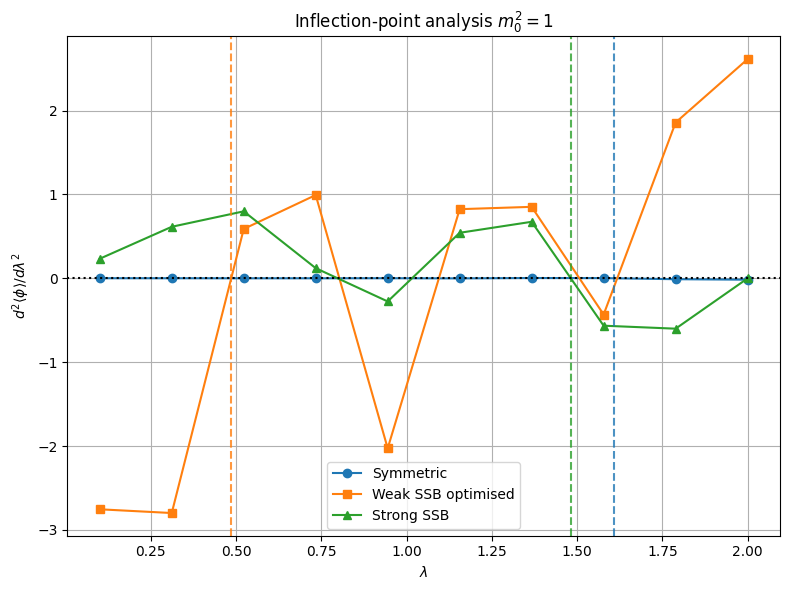

In [83]:
########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    d2M_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    d2M_weak,
    's-',
    label='Weak SSB optimised'
)

line3, = plt.plot(
    lambda_list,
    d2M_strong,
    '^-',
    label='Strong SSB'
)

# λc positions from inflection-point analysis

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

# Zero line

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1.5
)

plt.xlabel(r'$\lambda$')

plt.ylabel(
    r'$d^2\langle\phi\rangle/d\lambda^2$'
)

plt.title(
    r'Inflection-point analysis $m_0^2=1$'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


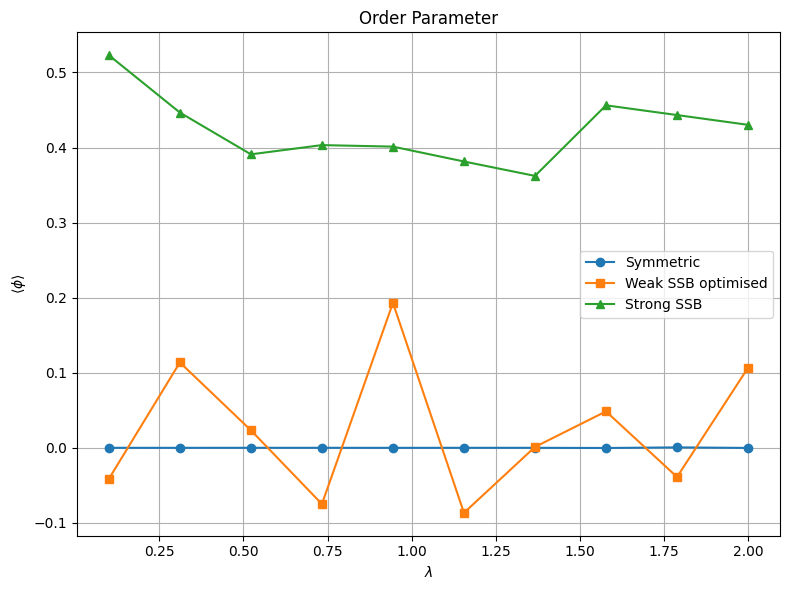

In [84]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_list,

    M_sym,

    'o-',

    label='Symmetric'
)

plt.plot(

    lambda_list,

    M_weak_opt,

    's-',

    label='Weak SSB optimised'
)

plt.plot(

    lambda_list,

    M_strong,

    '^-',

    label='Strong SSB'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title('Order Parameter')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

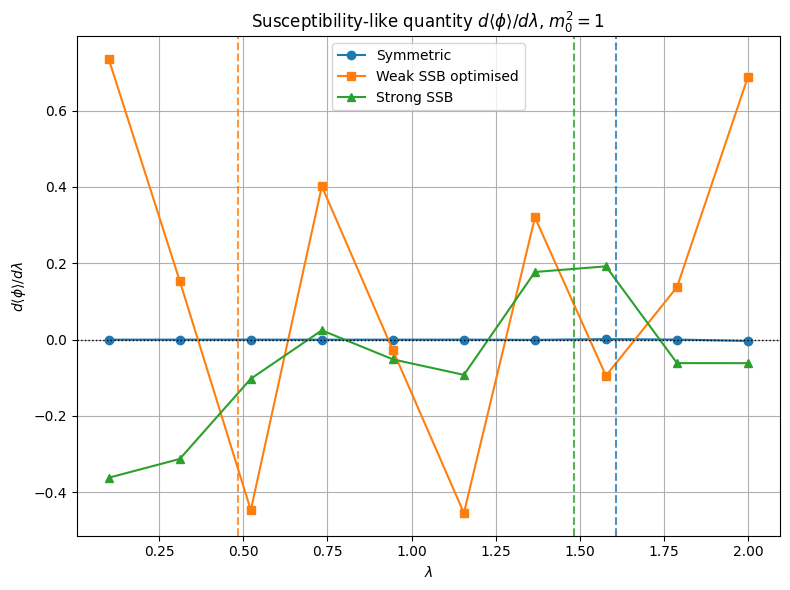

In [85]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    dM_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    dM_weak,
    's-',
    label='Weak SSB optimised'
)

line3, = plt.plot(
    lambda_list,
    dM_strong,
    '^-',
    label='Strong SSB'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_{0}^{2}=1$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
# ============================================================
# T scan values
# ============================================================

T_values = [

    1,2,5,10,20,30,40,50,75,100,
    125,150,175,200,225,250,275,300,
    400,500,600,700,800,900,
    1000,1010,1020,1030,1040,1050,
    1060,1070,1080,1090,1100,
    1200,1300,1400,1500,
    2000,
    2100,2110,2120,2130,2140,
    2150,2160,2170,2180,2190,
    2200,2300,2400,2500,
    2600,2700,2800,2900,3000
]

target_fidelity = 0.97

# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================

for data in all_results:

    label   = data['case']
    lam     = data['lambda']
    mI2     = data['mI2']
    f       = data['f']
    psi_vqe = data['psi_vqe']

    print("\n")
    print("="*80)
    print(f"CASE   : {label}")
    print(f"lambda : {lam:.3f}")
    print("="*80)

    # ========================================================
    # Final Hamiltonian
    # ========================================================

    Hs_final = two_site_hs(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=2.0,

        lam=lam,

        f=f,

        s=1.0
    )

    E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
    )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

    delta_min = minimum_gap_along_path(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=2.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    print(f"Minimum path gap = {delta_min:.8e}")

    # ========================================================
    # Scan T
    # ========================================================

    Tmin_found = None
    best_fidelity = 0.0

    for T in T_values:

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=T,

            mu=mu,

            mI2=mI2,

            m0_sq=2.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        F = fidelity(
            psi_T,
            psi_exact_final
        )

        best_fidelity = max(
            best_fidelity,
            F
        )

        print(
            f"T = {T:<5} "
            f"Fidelity = {F:.8f}"
        )

        if F >= target_fidelity:

            Tmin_found = T
            break

    # ========================================================
    # Diagnostics
    # ========================================================

    P0 = None
    P1 = None
    P01 = None
    final_gap = None

    if Tmin_found is None:

        print("\nFAILED POINT DIAGNOSTICS")

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=3000,

            mu=mu,

            mI2=mI2,

            m0_sq=2.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        evals, evecs = eigsh(

            Hs_final,

            k=3,

            which='SA'
        )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

        P0 = np.abs(np.vdot(psi0, psi_T))**2
        P1 = np.abs(np.vdot(psi1, psi_T))**2
        P01 = P0 + P1

        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
        print(f"P0     = {P0:.8f}")
        print(f"P1     = {P1:.8f}")
        print(f"P0+P1  = {P01:.8f}")

    # ========================================================
    # Store
    # ========================================================

    adiabatic_results.append({

        'case': label,
        'lambda': lam,
        'mI2': mI2,
        'f': f,

        'Tmin': Tmin_found,

        'best_fidelity': best_fidelity,

        'delta_min': delta_min,

        'P0': P0,
        'P1': P1,
        'P01': P01,

        'final_gap': final_gap
    })

    print(
        f"\nMinimum T for Fidelity >= 0.97 : "
        f"{Tmin_found}"
    )

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    f"{'T_min':<10}"
    f"{'Best Fidelity':<18}"
    f"{'Delta_min':<18}"
    f"{'P0':<12}"
    f"{'P1':<12}"
    f"{'P0+P1':<12}"
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        f"{str(r['Tmin']):<10}"
        f"{r['best_fidelity']:<18.10f}"
        f"{r['delta_min']:<18.8e}"
        f"{str(None if r['P0'] is None else round(r['P0'],6)):<12}"
        f"{str(None if r['P1'] is None else round(r['P1'],6)):<12}"
        f"{str(None if r['P01'] is None else round(r['P01'],6)):<12}"
    )



CASE   : Symmetric
lambda : 0.100
Minimum path gap = 1.01220263e+00
T = 1     Fidelity = 0.96521542
T = 2     Fidelity = 0.99334552

Minimum T for Fidelity >= 0.97 : 2


CASE   : Symmetric
lambda : 0.311
Minimum path gap = 1.03626623e+00
T = 1     Fidelity = 0.96805260
T = 2     Fidelity = 0.99422019

Minimum T for Fidelity >= 0.97 : 2


CASE   : Symmetric
lambda : 0.522
Minimum path gap = 1.05846299e+00
T = 1     Fidelity = 0.97048783

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 0.733
Minimum path gap = 1.07916278e+00
T = 1     Fidelity = 0.97256986

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 0.944
Minimum path gap = 1.09862393e+00
T = 1     Fidelity = 0.97441529

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 1.156
Minimum path gap = 1.11703633e+00
T = 1     Fidelity = 0.97606688

Minimum T for Fidelity >= 0.97 : 1


CASE   : Symmetric
lambda : 1.367
Minimum path gap = 1.13454489e+00
T = 1     Fidelity = 0.97754200

Minim

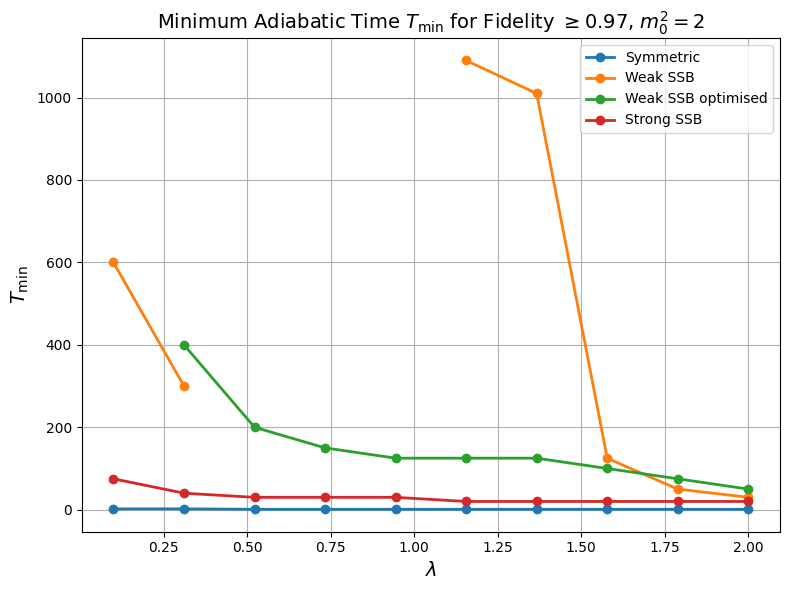

In [87]:
# ============================================================
# Plot T_min vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# Separate data by case
# ============================================================

case_data = {}

for r in adiabatic_results:

    case = r['case']

    if case not in case_data:

        case_data[case] = {

            'lambda': [],

            'Tmin': []
        }

    case_data[case]['lambda'].append(

        r['lambda']
    )

    case_data[case]['Tmin'].append(

        r['Tmin']
    )

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,6))

for case, d in case_data.items():

    plt.plot(

        d['lambda'],

        d['Tmin'],

        marker='o',

        linewidth=2,

        label=case
    )

# ============================================================
# Labels
# ============================================================

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$T_{\min}$', fontsize=14)

plt.title(

    r'Minimum Adiabatic Time $T_{\min}$ '
    r'for Fidelity $\geq 0.97$, $m_{0}^{2}=2$',

    fontsize=14
)

plt.grid(True)

plt.legend()

plt.tight_layout()
plt.savefig(
    "HEA_adiabatic time vs lambda.pdf",
    bbox_inches='tight'
)
plt.show()

In [88]:
# ============================================================
# GAP ANALYSIS
# ============================================================

from scipy.sparse.linalg import eigsh

gap_sym = []
gap_weak_opt = []
gap_strong = []

# ------------------------------------------------------------
# Symmetric
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=1.0,
        m0_sq=2.0,
        lam=lam,
        f=0.0,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_sym.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Weak SSB optimized
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=2.0,
        lam=lam,
        f=5*1e-2,          # optimized value
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_weak_opt.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Strong SSB
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=2.0,
        lam=lam,
        f=0.5,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_strong.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Critical λ
# ------------------------------------------------------------

lamc_sym = lambda_list[np.argmin(gap_sym)]
lamc_weak = lambda_list[np.argmin(gap_weak_opt)]
lamc_strong = lambda_list[np.argmin(gap_strong)]

print("\nGap minimum estimator")
print("----------------------")
print(f"Symmetric       λc = {lamc_sym:.4f}")
print(f"Weak SSB opt    λc = {lamc_weak:.4f}")
print(f"Strong SSB      λc = {lamc_strong:.4f}")


Gap minimum estimator
----------------------
Symmetric       λc = 0.1000
Weak SSB opt    λc = 0.1000
Strong SSB      λc = 0.1000


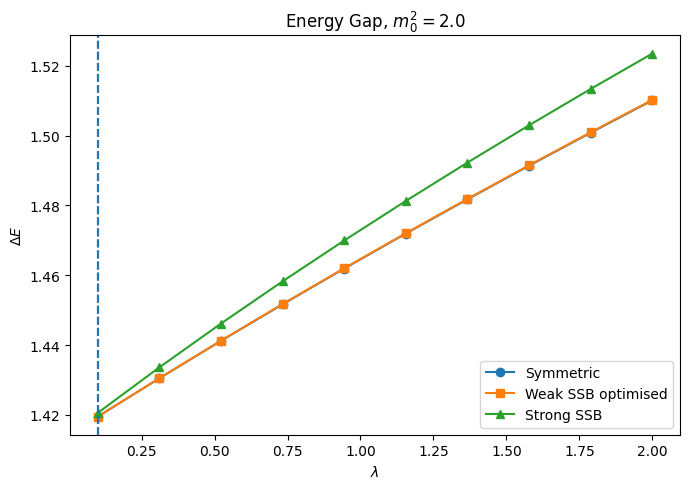

In [89]:
# ============================================================
# Plot : Gap vs lambda
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(lambda_list, gap_sym,
         'o-', label='Symmetric')

plt.plot(lambda_list, gap_weak_opt,
         's-', label='Weak SSB optimised')

plt.plot(lambda_list, gap_strong,
         '^-', label='Strong SSB')

plt.axvline(lamc_sym,
            ls='--')

plt.axvline(lamc_weak,
            ls='--')

plt.axvline(lamc_strong,
            ls='--')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Delta E$')
plt.title(r'Energy Gap, $m_{0}^{2}=2.0$')
plt.legend()

plt.tight_layout() 
plt.show()

In [90]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []
lambda_sym = []
lambda_weak_opt = []
lambda_strong = []
for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    Tmin = r['Tmin']
    # Skip if no Tmin was found

    if Tmin is None:
        continue

    if np.isnan(Tmin):
        continue

    mI2 = r['mI2']

    f = r['f']

    match = next(
        x for x in all_results
        if (
            x['case'] == case
            and np.isclose(x['lambda'], lam)
        )
    )

    psi_vqe = match['psi_vqe']

    psi_final = adiabatic_circuit_evolution(

        initial_state=psi_vqe,

        nq=nq_site,

        T=Tmin,

        mu=mu,

        mI2=mI2,

        m0_sq=2.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    M = np.real(

        np.vdot(

            psi_final,

            Phi_avg @ psi_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)
        lambda_sym.append(lam)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)
        lambda_weak_opt.append(lam)


    elif case == "Strong SSB":

        M_strong.append(M)
        lambda_strong.append(lam)

dict_keys(['case', 'lambda', 'mI2', 'f', 'Tmin', 'best_fidelity', 'delta_min', 'P0', 'P1', 'P01', 'final_gap'])


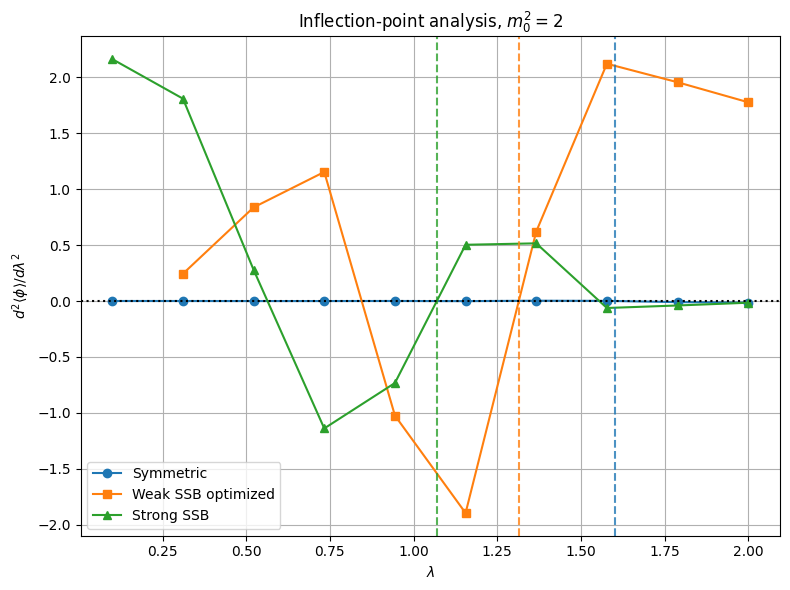

In [93]:
# ============================================================
# λc from inflection point
# ============================================================

# First derivatives

dM_sym = np.gradient(M_sym, lambda_sym)

dM_weak = np.gradient(M_weak_opt, lambda_weak_opt)

dM_strong = np.gradient(M_strong, lambda_strong)

# Second derivatives

d2M_sym = np.gradient(dM_sym, lambda_sym)

d2M_weak = np.gradient(dM_weak, lambda_weak_opt)

d2M_strong = np.gradient(dM_strong, lambda_strong)

# Third derivatives

d3M_sym = np.gradient(d2M_sym, lambda_sym)

d3M_weak = np.gradient(d2M_weak, lambda_weak_opt)

d3M_strong = np.gradient(d2M_strong, lambda_strong)



    
lamc_M_sym = find_lambda_c(
    lambda_sym,
    d2M_sym,
    d3M_sym, dM_sym
)

lamc_M_weak = find_lambda_c(
    lambda_weak_opt,
    d2M_weak,
    d3M_weak, dM_weak
)

lamc_M_strong = find_lambda_c(
    lambda_strong,
    d2M_strong,
    d3M_strong, dM_strong
)



########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_sym,
    d2M_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_weak_opt,
    d2M_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_strong,
    d2M_strong,
    '^-',
    label='Strong SSB'
)

# λc positions from inflection-point analysis

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

# Zero line

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1.5
)

plt.xlabel(r'$\lambda$')

plt.ylabel(
    r'$d^2\langle\phi\rangle/d\lambda^2$'
)

plt.title(
    r'Inflection-point analysis, $m_{0}^{2}=2$'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

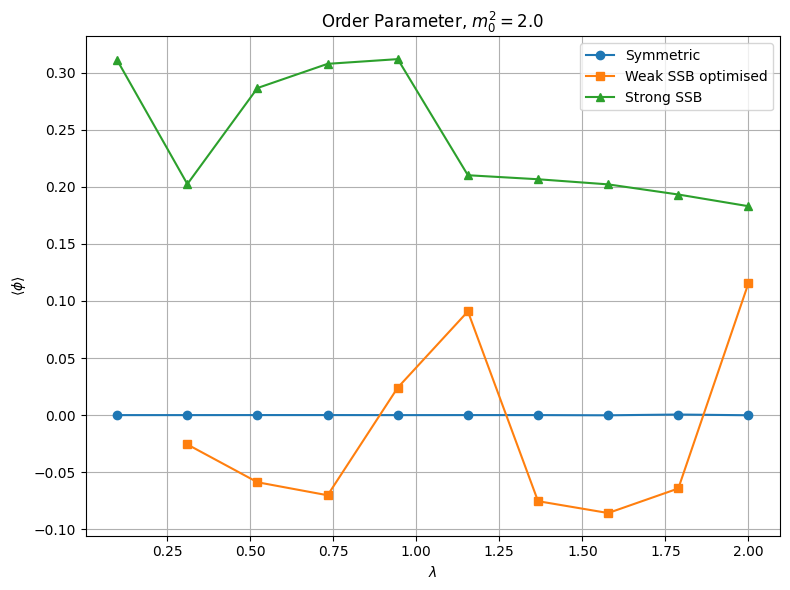

In [94]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_sym,

    M_sym,

    'o-',

    label='Symmetric'
)

plt.plot(

    lambda_weak_opt,

    M_weak_opt,

    's-',

    label='Weak SSB optimised'
)

plt.plot(

    lambda_strong,

    M_strong,

    '^-',

    label='Strong SSB'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title(r'Order Parameter, $m_{0}^{2}=2.0$')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

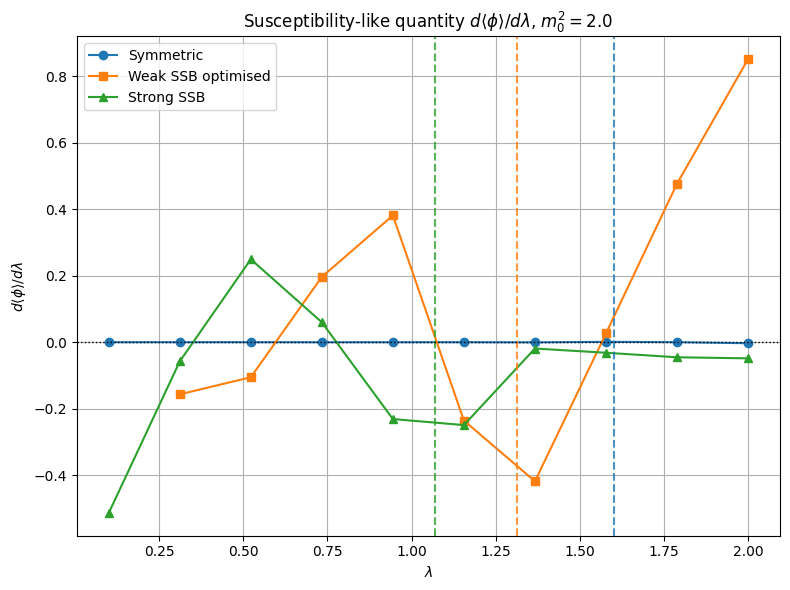

In [95]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_sym,
    dM_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_weak_opt,
    dM_weak,
    's-',
    label='Weak SSB optimised'
)

line3, = plt.plot(
    lambda_strong,
    dM_strong,
    '^-',
    label='Strong SSB'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_{0}^{2}=2.0$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
# ============================================================
# T scan values
# ============================================================

T_values = [

    1,2,5,10,20,30,40,50,75,100,
    125,150,175,200,225,250,275,300,
    400,500,600,700,800,900,
    1000,1010,1020,1030,1040,1050,
    1060,1070,1080,1090,1100,
    1200,1300,1400,1500,
    2000,
    2100,2110,2120,2130,2140,
    2150,2160,2170,2180,2190,
    2200,2300,2400,2500,
    2600,2700,2800,2900,3000
]

target_fidelity = 0.97

# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================

for data in all_results:

    label   = data['case']
    lam     = data['lambda']
    mI2     = data['mI2']
    f       = data['f']
    psi_vqe = data['psi_vqe']

    print("\n")
    print("="*80)
    print(f"CASE   : {label}")
    print(f"lambda : {lam:.3f}")
    print("="*80)

    # ========================================================
    # Final Hamiltonian
    # ========================================================

    Hs_final = two_site_hs(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=-1.0,

        lam=lam,

        f=f,

        s=1.0
    )

    E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
    )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

    delta_min = minimum_gap_along_path(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=-1.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    print(f"Minimum path gap = {delta_min:.8e}")

    # ========================================================
    # Scan T
    # ========================================================

    Tmin_found = None
    best_fidelity = 0.0

    for T in T_values:

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=T,

            mu=mu,

            mI2=mI2,

            m0_sq=-1.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        F = fidelity(
            psi_T,
            psi_exact_final
        )

        best_fidelity = max(
            best_fidelity,
            F
        )

        print(
            f"T = {T:<5} "
            f"Fidelity = {F:.8f}"
        )

        if F >= target_fidelity:

            Tmin_found = T
            break

    # ========================================================
    # Diagnostics
    # ========================================================

    P0 = None
    P1 = None
    P01 = None
    final_gap = None

    if Tmin_found is None:

        print("\nFAILED POINT DIAGNOSTICS")

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=3000,

            mu=mu,

            mI2=mI2,

            m0_sq=-1.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        evals, evecs = eigsh(

            Hs_final,

            k=3,

            which='SA'
        )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

        P0 = np.abs(np.vdot(psi0, psi_T))**2
        P1 = np.abs(np.vdot(psi1, psi_T))**2
        P01 = P0 + P1

        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
        print(f"P0     = {P0:.8f}")
        print(f"P1     = {P1:.8f}")
        print(f"P0+P1  = {P01:.8f}")

    # ========================================================
    # Store
    # ========================================================

    adiabatic_results.append({

        'case': label,
        'lambda': lam,
        'mI2': mI2,
        'f': f,

        'Tmin': Tmin_found,

        'best_fidelity': best_fidelity,

        'delta_min': delta_min,

        'P0': P0,
        'P1': P1,
        'P01': P01,

        'final_gap': final_gap
    })

    print(
        f"\nMinimum T for Fidelity >= 0.97 : "
        f"{Tmin_found}"
    )

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    f"{'T_min':<10}"
    f"{'Best Fidelity':<18}"
    f"{'Delta_min':<18}"
    f"{'P0':<12}"
    f"{'P1':<12}"
    f"{'P0+P1':<12}"
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        f"{str(r['Tmin']):<10}"
        f"{r['best_fidelity']:<18.10f}"
        f"{r['delta_min']:<18.8e}"
        f"{str(None if r['P0'] is None else round(r['P0'],6)):<12}"
        f"{str(None if r['P1'] is None else round(r['P1'],6)):<12}"
        f"{str(None if r['P01'] is None else round(r['P01'],6)):<12}"
    )



CASE   : Symmetric
lambda : 0.100
Minimum path gap = 2.15534848e-04
T = 1     Fidelity = 0.00000000
T = 2     Fidelity = 0.00000000
T = 5     Fidelity = 0.00009539
T = 10    Fidelity = 0.00119243
T = 20    Fidelity = 0.02687565
T = 30    Fidelity = 0.09667553
T = 40    Fidelity = 0.19610145
T = 50    Fidelity = 0.31173350
T = 75    Fidelity = 0.56619752
T = 100   Fidelity = 0.72002314
T = 125   Fidelity = 0.80739257
T = 150   Fidelity = 0.86470589
T = 175   Fidelity = 0.90864818
T = 200   Fidelity = 0.94629935
T = 225   Fidelity = 0.96686785
T = 250   Fidelity = 0.95352113
T = 275   Fidelity = 0.98204188

Minimum T for Fidelity >= 0.97 : 275


CASE   : Symmetric
lambda : 0.311
Minimum path gap = 1.15624068e-06
T = 1     Fidelity = 0.00000001
T = 2     Fidelity = 0.00000045
T = 5     Fidelity = 0.00144340
T = 10    Fidelity = 0.10202321
T = 20    Fidelity = 0.52981231
T = 30    Fidelity = 0.63895421
T = 40    Fidelity = 0.76792629
T = 50    Fidelity = 0.88384886
T = 75    Fidelity = 0

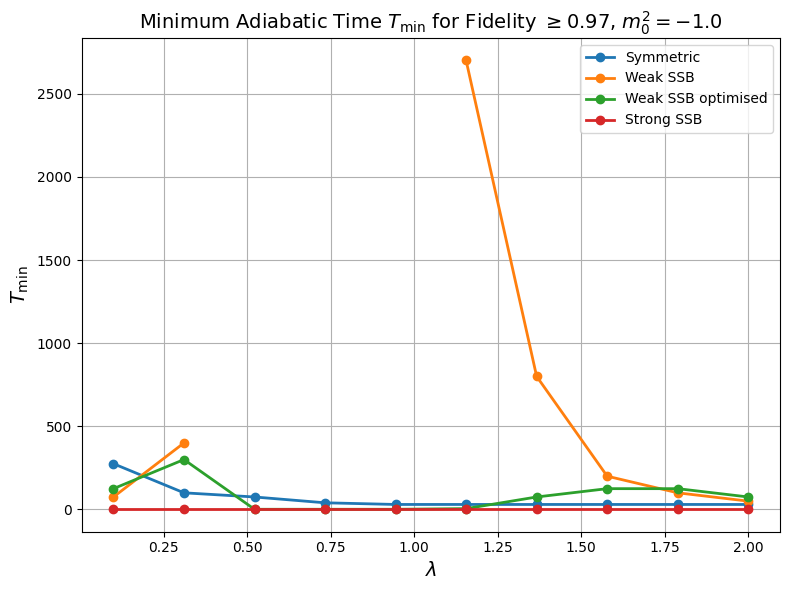

In [97]:
# ============================================================
# Plot T_min vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# Separate data by case
# ============================================================

case_data = {}

for r in adiabatic_results:

    case = r['case']

    if case not in case_data:

        case_data[case] = {

            'lambda': [],

            'Tmin': []
        }

    case_data[case]['lambda'].append(

        r['lambda']
    )

    case_data[case]['Tmin'].append(

        r['Tmin']
    )

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,6))

for case, d in case_data.items():

    plt.plot(

        d['lambda'],

        d['Tmin'],

        marker='o',

        linewidth=2,

        label=case
    )

# ============================================================
# Labels
# ============================================================

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$T_{\min}$', fontsize=14)

plt.title(

    r'Minimum Adiabatic Time $T_{\min}$ '
    r'for Fidelity $\geq 0.97$, $m_{0}^{2}=-1.0$',

    fontsize=14
)

plt.grid(True)

plt.legend()

plt.tight_layout()
plt.savefig(
    "HEA_adiabatic time vs lambda.pdf",
    bbox_inches='tight'
)
plt.show()

In [98]:
# ============================================================
# GAP ANALYSIS
# ============================================================

from scipy.sparse.linalg import eigsh

gap_sym = []
gap_weak_opt = []
gap_strong = []

# ------------------------------------------------------------
# Symmetric
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=1.0,
        m0_sq=-1.0,
        lam=lam,
        f=0.0,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_sym.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Weak SSB optimized
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=-1.0,
        lam=lam,
        f=5*1e-2,          # optimized value
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_weak_opt.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Strong SSB
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=-1.0,
        lam=lam,
        f=0.5,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_strong.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Critical λ
# ------------------------------------------------------------

lamc_sym = lambda_list[np.argmin(gap_sym)]
lamc_weak = lambda_list[np.argmin(gap_weak_opt)]
lamc_strong = lambda_list[np.argmin(gap_strong)]

print("\nGap minimum estimator")
print("----------------------")
print(f"Symmetric       λc = {lamc_sym:.4f}")
print(f"Weak SSB opt    λc = {lamc_weak:.4f}")
print(f"Strong SSB      λc = {lamc_strong:.4f}")


Gap minimum estimator
----------------------
Symmetric       λc = 0.5222
Weak SSB opt    λc = 2.0000
Strong SSB      λc = 2.0000


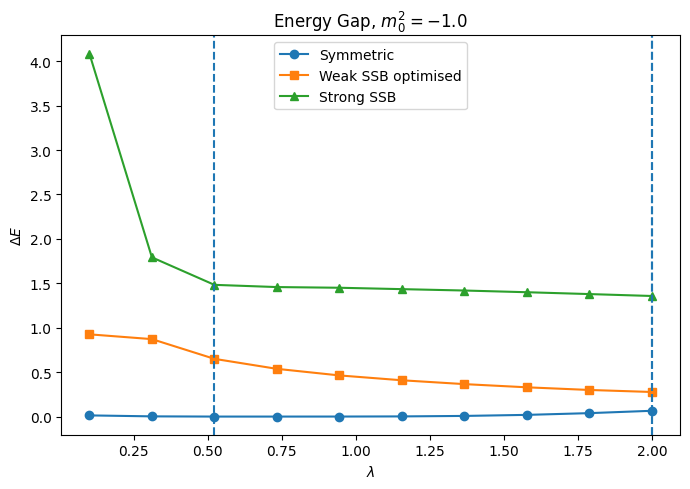

In [99]:
# ============================================================
# Plot : Gap vs lambda
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(lambda_list, gap_sym,
         'o-', label='Symmetric')

plt.plot(lambda_list, gap_weak_opt,
         's-', label='Weak SSB optimised')

plt.plot(lambda_list, gap_strong,
         '^-', label='Strong SSB')

plt.axvline(lamc_sym,
            ls='--')

plt.axvline(lamc_weak,
            ls='--')

plt.axvline(lamc_strong,
            ls='--')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Delta E$')
plt.title(r'Energy Gap, $m_{0}^{2}=-1.0$')
plt.legend()

plt.tight_layout()
plt.show()

In [100]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []
lambda_sym = []
lambda_weak_opt = []
lambda_strong = []
for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    Tmin = r['Tmin']
    # Skip if no Tmin was found

    if Tmin is None:
        continue

    if np.isnan(Tmin):
        continue

    mI2 = r['mI2']

    f = r['f']

    match = next(
        x for x in all_results
        if (
            x['case'] == case
            and np.isclose(x['lambda'], lam)
        )
    )

    psi_vqe = match['psi_vqe']

    psi_final = adiabatic_circuit_evolution(

        initial_state=psi_vqe,

        nq=nq_site,

        T=Tmin,

        mu=mu,

        mI2=mI2,

        m0_sq=-1.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    M = np.real(

        np.vdot(

            psi_final,

            Phi_avg @ psi_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)
        lambda_sym.append(lam)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)
        lambda_weak_opt.append(lam)

    elif case == "Strong SSB":

        M_strong.append(M)
        lambda_strong.append(lam)

dict_keys(['case', 'lambda', 'mI2', 'f', 'Tmin', 'best_fidelity', 'delta_min', 'P0', 'P1', 'P01', 'final_gap'])


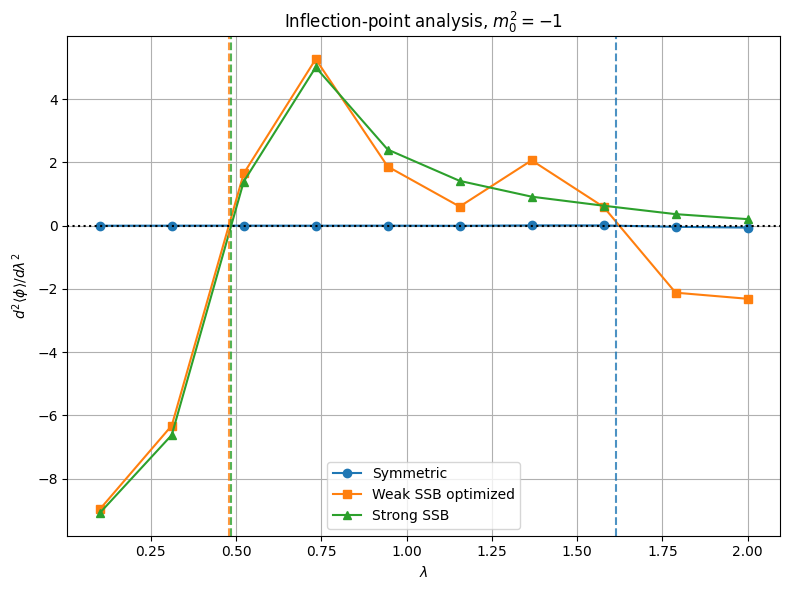

In [101]:
# ============================================================
# λc from inflection point
# ============================================================

# First derivatives

dM_sym = np.gradient(M_sym, lambda_sym)

dM_weak = np.gradient(M_weak_opt, lambda_weak_opt)

dM_strong = np.gradient(M_strong, lambda_strong)

# Second derivatives

d2M_sym = np.gradient(dM_sym, lambda_sym)

d2M_weak = np.gradient(dM_weak, lambda_weak_opt)

d2M_strong = np.gradient(dM_strong, lambda_strong)

# Third derivatives

d3M_sym = np.gradient(d2M_sym, lambda_sym)

d3M_weak = np.gradient(d2M_weak, lambda_weak_opt)

d3M_strong = np.gradient(d2M_strong, lambda_strong)




lamc_M_sym = find_lambda_c(
    lambda_sym,
    d2M_sym,
    d3M_sym, dM_sym
)

lamc_M_weak = find_lambda_c(
    lambda_weak_opt,
    d2M_weak,
    d3M_weak, dM_weak
)

lamc_M_strong = find_lambda_c(
    lambda_strong,
    d2M_strong,
    d3M_strong, dM_strong
)


########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    d2M_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    d2M_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    d2M_strong,
    '^-',
    label='Strong SSB'
)

# λc positions from inflection-point analysis

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

# Zero line

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1.5
)

plt.xlabel(r'$\lambda$')

plt.ylabel(
    r'$d^2\langle\phi\rangle/d\lambda^2$'
)

plt.title(
    r'Inflection-point analysis, $m_{0}^{2}=-1$'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

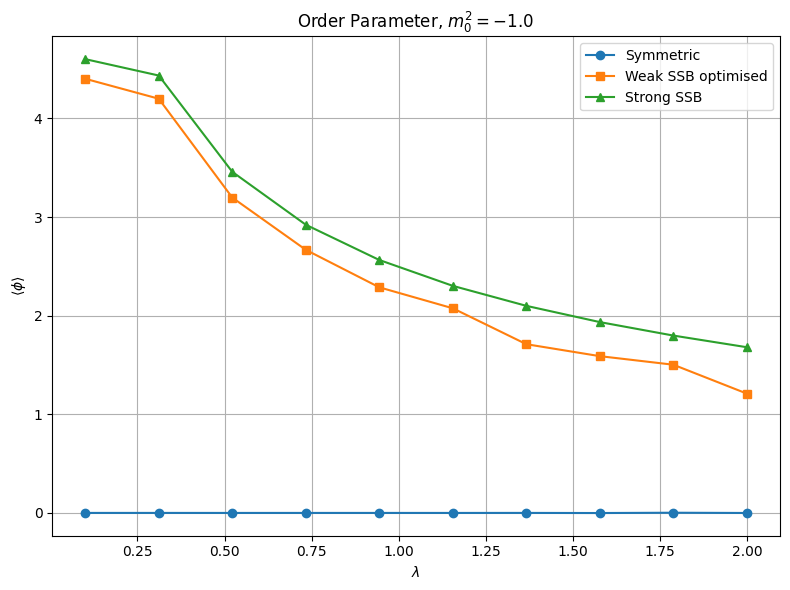

In [102]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_sym,

    M_sym,

    'o-',

    label='Symmetric'
)

plt.plot(

    lambda_weak_opt,

    M_weak_opt,

    's-',

    label='Weak SSB optimised'
)

plt.plot(

    lambda_strong,

    M_strong,

    '^-',

    label='Strong SSB'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title(r'Order Parameter, $m_{0}^{2}=-1.0$')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

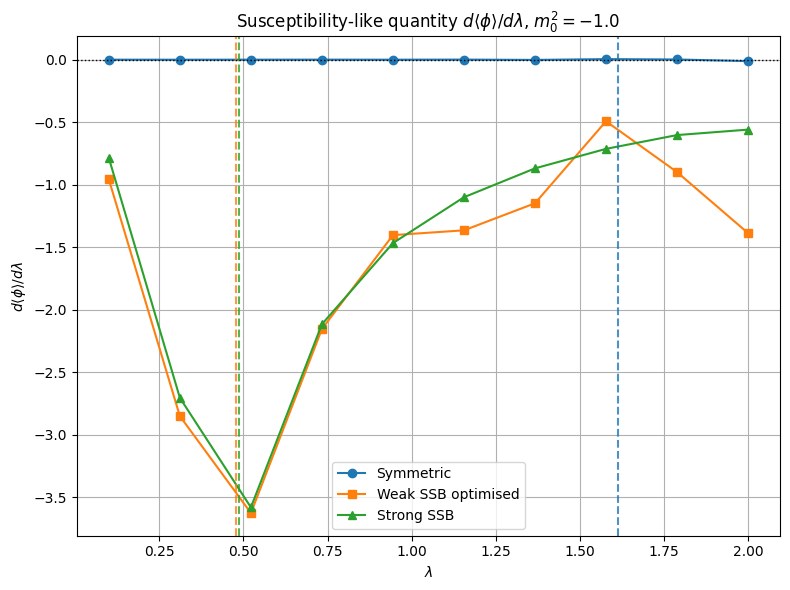

In [103]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_sym,
    dM_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_weak_opt,
    dM_weak,
    's-',
    label='Weak SSB optimised'
)

line3, = plt.plot(
    lambda_strong,
    dM_strong,
    '^-',
    label='Strong SSB'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_{0}^{2}=-1.0$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [104]:
# ============================================================
# T scan values
# ============================================================

T_values = [

    1,2,5,10,20,30,40,50,75,100,
    125,150,175,200,225,250,275,300,
    400,500,600,700,800,900,
    1000,1010,1020,1030,1040,1050,
    1060,1070,1080,1090,1100,
    1200,1300,1400,1500,
    2000,
    2100,2110,2120,2130,2140,
    2150,2160,2170,2180,2190,
    2200,2300,2400,2500,
    2600,2700,2800,2900,3000
]

target_fidelity = 0.97

# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================

for data in all_results:

    label   = data['case']
    lam     = data['lambda']
    mI2     = data['mI2']
    f       = data['f']
    psi_vqe = data['psi_vqe']

    print("\n")
    print("="*80)
    print(f"CASE   : {label}")
    print(f"lambda : {lam:.3f}")
    print("="*80)

    # ========================================================
    # Final Hamiltonian
    # ========================================================

    Hs_final = two_site_hs(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=-2.0,

        lam=lam,

        f=f,

        s=1.0
    )

    E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
    )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

    delta_min = minimum_gap_along_path(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=-2.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    print(f"Minimum path gap = {delta_min:.8e}")

    # ========================================================
    # Scan T
    # ========================================================

    Tmin_found = None
    best_fidelity = 0.0

    for T in T_values:

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=T,

            mu=mu,

            mI2=mI2,

            m0_sq=-2.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        F = fidelity(
            psi_T,
            psi_exact_final
        )

        best_fidelity = max(
            best_fidelity,
            F
        )

        print(
            f"T = {T:<5} "
            f"Fidelity = {F:.8f}"
        )

        if F >= target_fidelity:

            Tmin_found = T
            break

    # ========================================================
    # Diagnostics
    # ========================================================

    P0 = None
    P1 = None
    P01 = None
    final_gap = None

    if Tmin_found is None:

        print("\nFAILED POINT DIAGNOSTICS")

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=3000,

            mu=mu,

            mI2=mI2,

            m0_sq=-2.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        evals, evecs = eigsh(

            Hs_final,

            k=3,

            which='SA'
        )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

        P0 = np.abs(np.vdot(psi0, psi_T))**2
        P1 = np.abs(np.vdot(psi1, psi_T))**2
        P01 = P0 + P1

        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
        print(f"P0     = {P0:.8f}")
        print(f"P1     = {P1:.8f}")
        print(f"P0+P1  = {P01:.8f}")

    # ========================================================
    # Store
    # ========================================================

    adiabatic_results.append({

        'case': label,
        'lambda': lam,
        'mI2': mI2,
        'f': f,

        'Tmin': Tmin_found,

        'best_fidelity': best_fidelity,

        'delta_min': delta_min,

        'P0': P0,
        'P1': P1,
        'P01': P01,

        'final_gap': final_gap
    })

    print(
        f"\nMinimum T for Fidelity >= 0.97 : "
        f"{Tmin_found}"
    )

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    f"{'T_min':<10}"
    f"{'Best Fidelity':<18}"
    f"{'Delta_min':<18}"
    f"{'P0':<12}"
    f"{'P1':<12}"
    f"{'P0+P1':<12}"
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        f"{str(r['Tmin']):<10}"
        f"{r['best_fidelity']:<18.10f}"
        f"{r['delta_min']:<18.8e}"
        f"{str(None if r['P0'] is None else round(r['P0'],6)):<12}"
        f"{str(None if r['P1'] is None else round(r['P1'],6)):<12}"
        f"{str(None if r['P01'] is None else round(r['P01'],6)):<12}"
    )



CASE   : Symmetric
lambda : 0.100
Minimum path gap = 3.07240439e-04
T = 1     Fidelity = 0.00000000
T = 2     Fidelity = 0.00000000
T = 5     Fidelity = 0.00000296
T = 10    Fidelity = 0.00027935
T = 20    Fidelity = 0.00630222
T = 30    Fidelity = 0.02604271
T = 40    Fidelity = 0.06582131
T = 50    Fidelity = 0.12447402
T = 75    Fidelity = 0.30902490
T = 100   Fidelity = 0.46391449
T = 125   Fidelity = 0.64204587
T = 150   Fidelity = 0.69157903
T = 175   Fidelity = 0.77469501
T = 200   Fidelity = 0.83395601
T = 225   Fidelity = 0.81461166
T = 250   Fidelity = 0.90536270
T = 275   Fidelity = 0.91626554
T = 300   Fidelity = 0.86715849
T = 400   Fidelity = 0.97880039

Minimum T for Fidelity >= 0.97 : 400


CASE   : Symmetric
lambda : 0.311
Minimum path gap = 1.17908351e-06
T = 1     Fidelity = 0.00000000
T = 2     Fidelity = 0.00000001
T = 5     Fidelity = 0.00030473
T = 10    Fidelity = 0.01973021
T = 20    Fidelity = 0.35207634
T = 30    Fidelity = 0.52579956
T = 40    Fidelity = 0

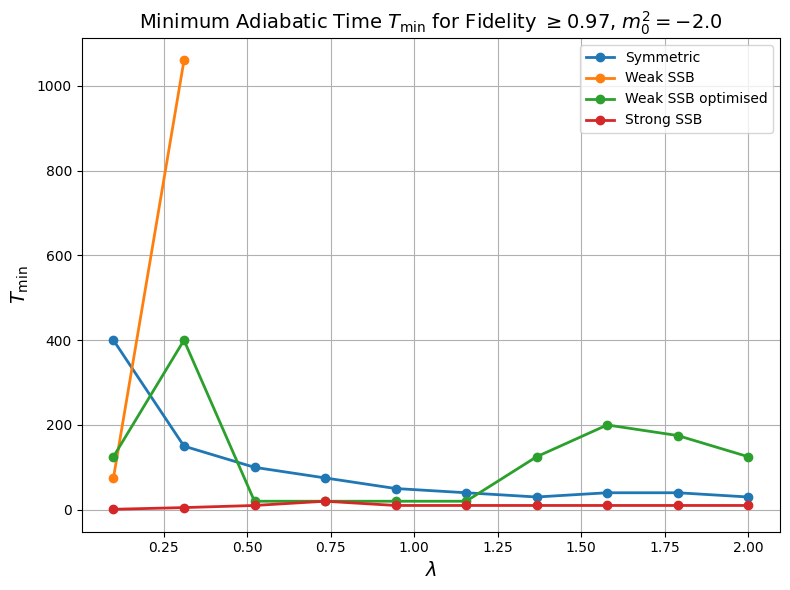

In [105]:
# ============================================================
# Plot T_min vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# Separate data by case
# ============================================================

case_data = {}

for r in adiabatic_results:

    case = r['case']

    if case not in case_data:

        case_data[case] = {

            'lambda': [],

            'Tmin': []
        }

    case_data[case]['lambda'].append(

        r['lambda']
    )

    case_data[case]['Tmin'].append(

        r['Tmin']
    )

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,6))

for case, d in case_data.items():

    plt.plot(

        d['lambda'],

        d['Tmin'],

        marker='o',

        linewidth=2,

        label=case
    )

# ============================================================
# Labels
# ============================================================

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$T_{\min}$', fontsize=14)

plt.title(

    r'Minimum Adiabatic Time $T_{\min}$ '
    r'for Fidelity $\geq 0.97$, $m_{0}^{2}=-2.0$',

    fontsize=14
)

plt.grid(True)

plt.legend()

plt.tight_layout()
plt.savefig(
    "HEA_adiabatic time vs lambda.pdf",
    bbox_inches='tight'
)
plt.show()

In [106]:
# ============================================================
# GAP ANALYSIS
# ============================================================

from scipy.sparse.linalg import eigsh

gap_sym = []
gap_weak_opt = []
gap_strong = []

# ------------------------------------------------------------
# Symmetric
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=1.0,
        m0_sq=-2.0,
        lam=lam,
        f=0.0,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_sym.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Weak SSB optimized
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=-2.0,
        lam=lam,
        f=5*1e-2,          # optimized value
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_weak_opt.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Strong SSB
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=-2.0,
        lam=lam,
        f=0.5,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_strong.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Critical λ
# ------------------------------------------------------------

lamc_sym = lambda_list[np.argmin(gap_sym)]
lamc_weak = lambda_list[np.argmin(gap_weak_opt)]
lamc_strong = lambda_list[np.argmin(gap_strong)]

print("\nGap minimum estimator")
print("----------------------")
print(f"Symmetric       λc = {lamc_sym:.4f}")
print(f"Weak SSB opt    λc = {lamc_weak:.4f}")
print(f"Strong SSB      λc = {lamc_strong:.4f}")


Gap minimum estimator
----------------------
Symmetric       λc = 1.1556
Weak SSB opt    λc = 2.0000
Strong SSB      λc = 0.7333


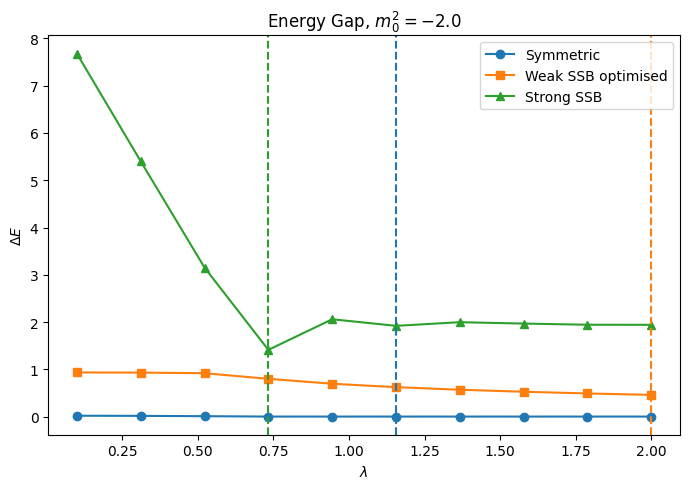

In [107]:
# ============================================================
# Plot : Gap vs lambda
# ============================================================

plt.figure(figsize=(7,5))

line1,=plt.plot(lambda_list, gap_sym,
         'o-', label='Symmetric')

line2,=plt.plot(lambda_list, gap_weak_opt,
         's-', label='Weak SSB optimised')

line3,=plt.plot(lambda_list, gap_strong,
         '^-', label='Strong SSB')

plt.axvline(lamc_sym,
            ls='--',
           color=line1.get_color())

plt.axvline(lamc_weak,
            ls='--',
           color=line2.get_color())

plt.axvline(lamc_strong,
            ls='--',
           color=line3.get_color())

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Delta E$')
plt.title(r'Energy Gap, $m_{0}^{2}=-2.0$')
plt.legend()

plt.tight_layout()
plt.show()

In [108]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []
lambda_sym = []
lambda_weak_opt = []
lambda_strong = []
for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    Tmin = r['Tmin']
    # Skip if no Tmin was found

    if Tmin is None:
        continue

    if np.isnan(Tmin):
        continue

    mI2 = r['mI2']

    f = r['f']

    match = next(
        x for x in all_results
        if (
            x['case'] == case
            and np.isclose(x['lambda'], lam)
        )
    )

    psi_vqe = match['psi_vqe']

    psi_final = adiabatic_circuit_evolution(

        initial_state=psi_vqe,

        nq=nq_site,

        T=Tmin,

        mu=mu,

        mI2=mI2,

        m0_sq=-2.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    M = np.real(

        np.vdot(

            psi_final,

            Phi_avg @ psi_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)
        lambda_sym.append(lam)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)
        lambda_weak_opt.append(lam)

    elif case == "Strong SSB":

        M_strong.append(M)
        lambda_strong.append(lam)

dict_keys(['case', 'lambda', 'mI2', 'f', 'Tmin', 'best_fidelity', 'delta_min', 'P0', 'P1', 'P01', 'final_gap'])


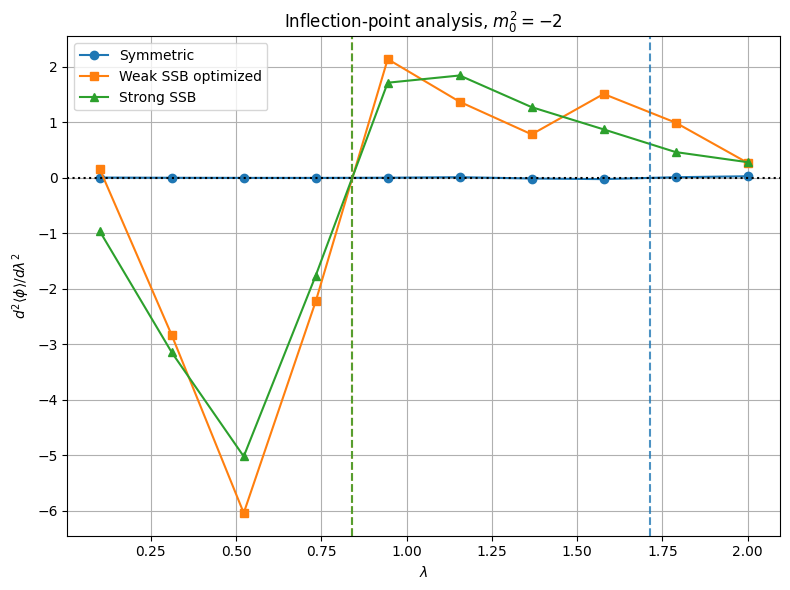

In [109]:
# ============================================================
# λc from inflection point
# ============================================================

# First derivatives

dM_sym = np.gradient(M_sym, lambda_sym)

dM_weak = np.gradient(M_weak_opt, lambda_weak_opt)

dM_strong = np.gradient(M_strong, lambda_strong)

# Second derivatives

d2M_sym = np.gradient(dM_sym, lambda_sym)

d2M_weak = np.gradient(dM_weak, lambda_weak_opt)

d2M_strong = np.gradient(dM_strong, lambda_strong)

# Third derivatives

d3M_sym = np.gradient(d2M_sym, lambda_sym)

d3M_weak = np.gradient(d2M_weak, lambda_weak_opt)

d3M_strong = np.gradient(d2M_strong, lambda_strong)



lamc_M_sym = find_lambda_c(
    lambda_sym,
    d2M_sym,
    d3M_sym, dM_sym
)

lamc_M_weak = find_lambda_c(
    lambda_weak_opt,
    d2M_weak,
    d3M_weak, dM_weak
)

lamc_M_strong = find_lambda_c(
    lambda_strong,
    d2M_strong,
    d3M_strong, dM_strong
)



########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    d2M_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    d2M_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    d2M_strong,
    '^-',
    label='Strong SSB'
)

# λc positions from inflection-point analysis

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

# Zero line

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1.5
)

plt.xlabel(r'$\lambda$')

plt.ylabel(
    r'$d^2\langle\phi\rangle/d\lambda^2$'
)

plt.title(
    r'Inflection-point analysis, $m_{0}^{2}=-2$'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

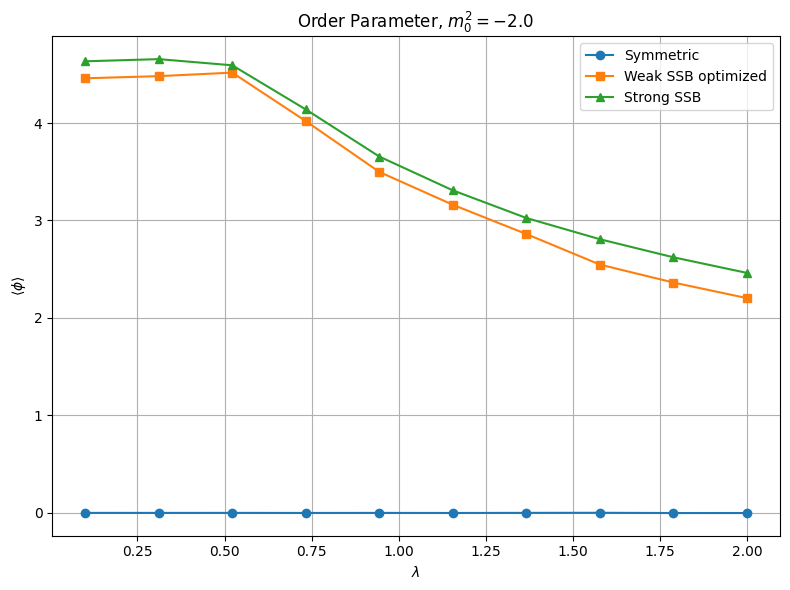

In [110]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_sym,

    M_sym,

    'o-',

    label='Symmetric'
)

plt.plot(

    lambda_weak_opt,

    M_weak_opt,

    's-',

    label='Weak SSB optimized'
)

plt.plot(

    lambda_strong,

    M_strong,

    '^-',

    label='Strong SSB'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title(r'Order Parameter, $m_{0}^{2}=-2.0$')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

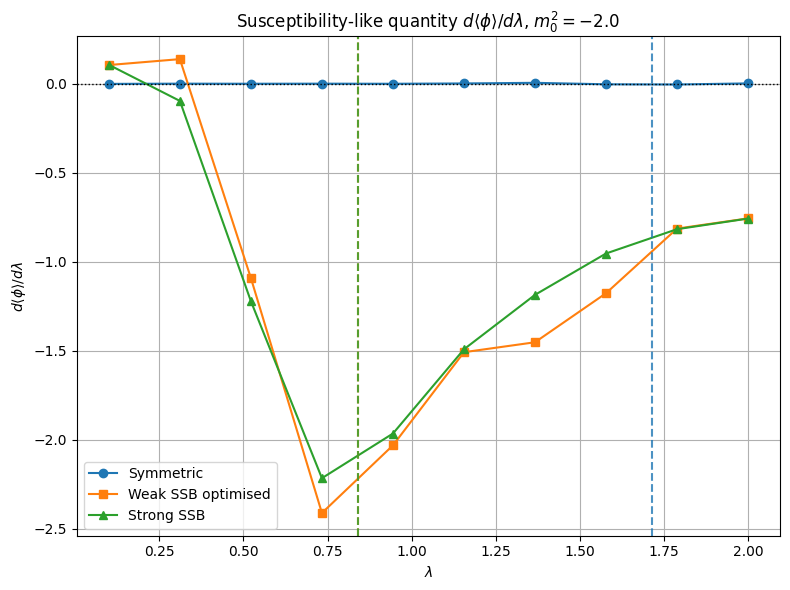

In [111]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_sym,
    dM_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_weak_opt,
    dM_weak,
    's-',
    label='Weak SSB optimised'
)

line3, = plt.plot(
    lambda_strong,
    dM_strong,
    '^-',
    label='Strong SSB'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_{0}^{2}=-2.0$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()